In [22]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

df = pd.read_csv("../data/time_series_country.csv")
df.head()
df.info()
df["Country"].unique()
for c in sorted(df["Country"].unique()):
    print(c)

<class 'pandas.DataFrame'>
RangeIndex: 3056 entries, 0 to 3055
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         3056 non-null   str    
 1   Subregion       3056 non-null   str    
 2   Year            3056 non-null   int64  
 3   Country Code    3056 non-null   str    
 4   Total_Deaths    3056 non-null   float64
 5   Region          3056 non-null   str    
 6   Population      3056 non-null   float64
 7   Mortality_Rate  3056 non-null   float64
dtypes: float64(3), int64(1), str(4)
memory usage: 191.1 KB
Afghanistan
Albania
Algeria
American Samoa
Angola
Antigua and Barbuda
Argentina
Armenia
Australia
Austria
Azerbaijan
Bahamas
Bangladesh
Barbados
Belarus
Belgium
Belize
Benin
Bermuda
Bhutan
Bolivia (Plurinational State of)
Bosnia and Herzegovina
Botswana
Brazil
British Virgin Islands
Bulgaria
Burkina Faso
Burundi
Cabo Verde
Cambodia
Cameroon
Canada
Cayman Islands
Central African Republic
Chad


# 4.1 Global Analysis

ADF Statistic: -4.903379367148169
p-value: 3.4349976943603684e-05
ADF Statistic (Differenced): -3.364404564500117
p-value (Differenced): 0.012233848428242496


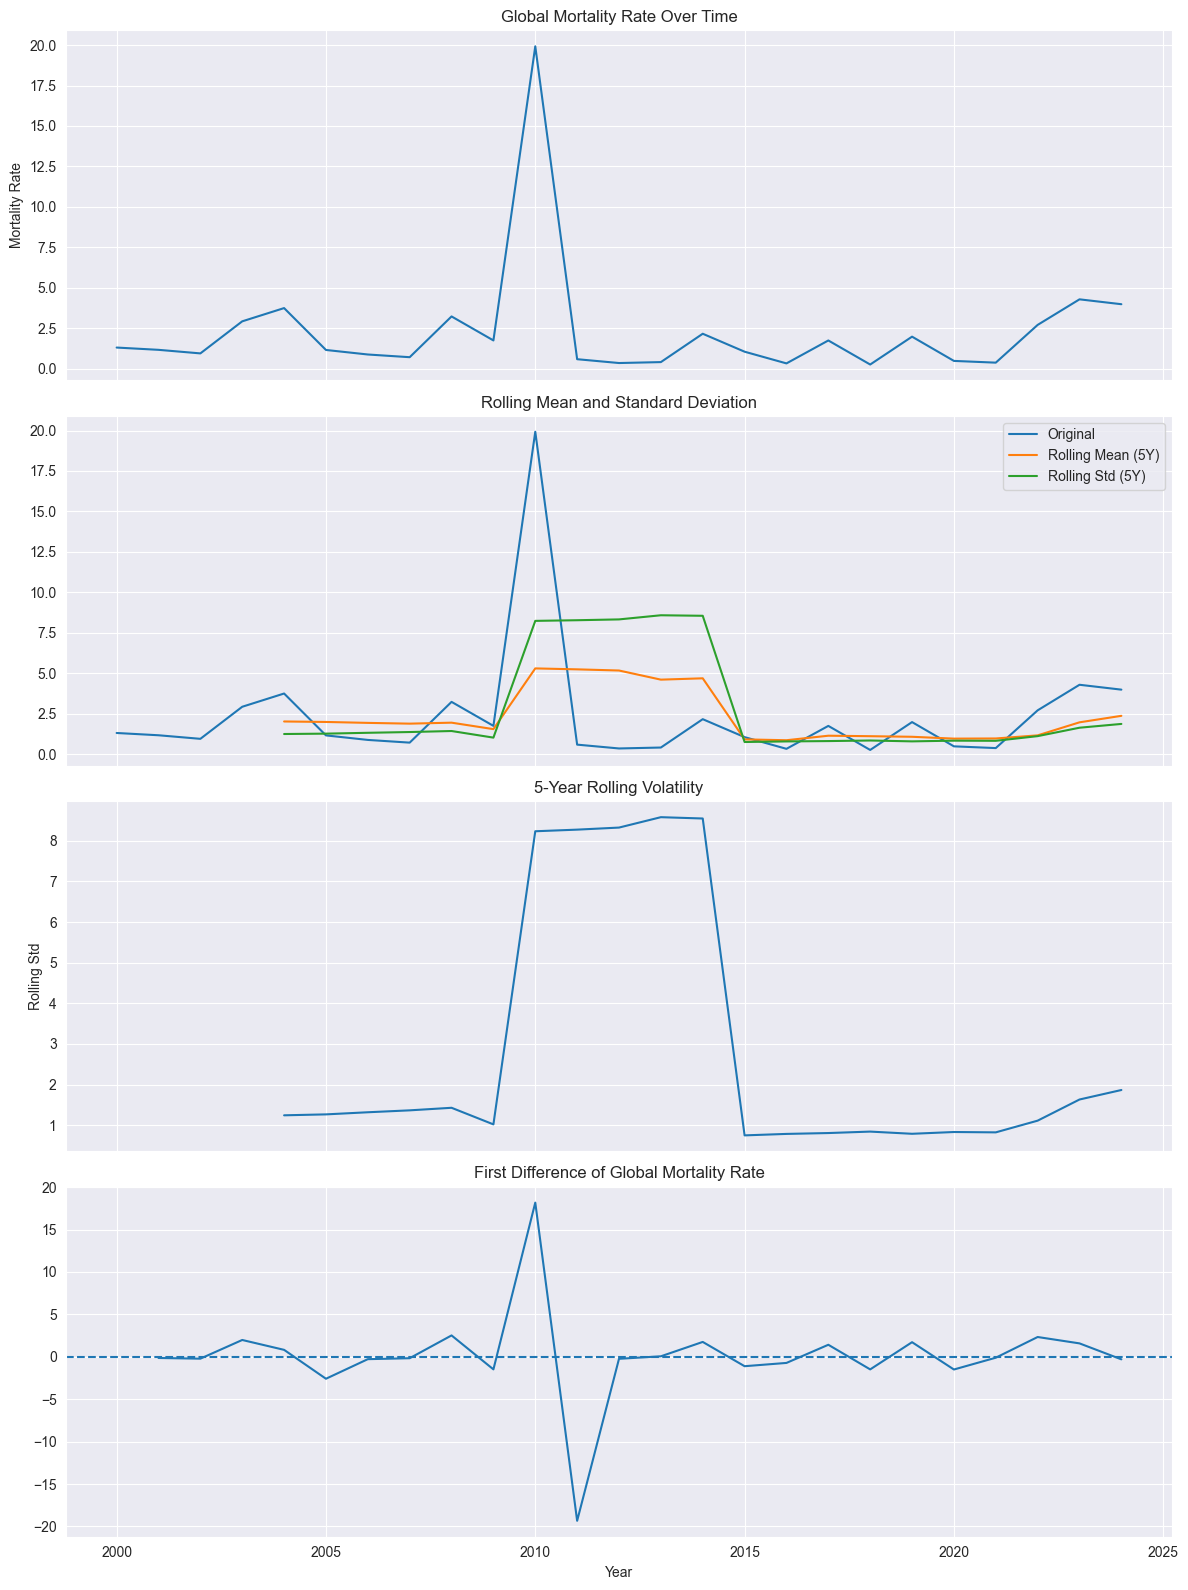

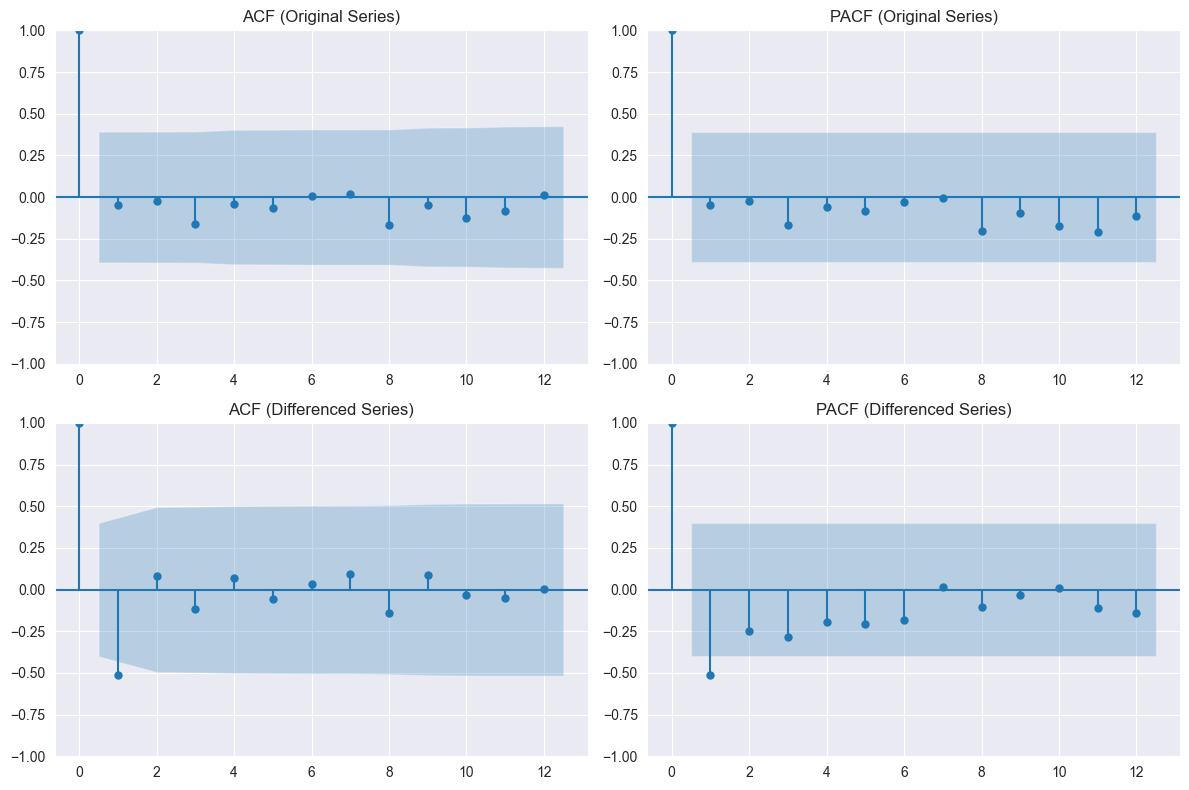

In [40]:
# 4.1.1 Global Trend

global_ts = (
    df.groupby("Year")["Mortality_Rate"]
    .mean()
    .sort_index()
)

# 4.1.2 Rolling Statistics

rolling_mean = global_ts.rolling(window=5).mean()
rolling_std = global_ts.rolling(window=5).std()

# 4.1.3 Stationarity (ADF Test)

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(global_ts)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

# First Difference
diff_ts = global_ts.diff().dropna()

adf_diff = adfuller(diff_ts)

print("ADF Statistic (Differenced):", adf_diff[0])
print("p-value (Differenced):", adf_diff[1])

#Trend + Rolling + Volatility + Diff

fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

# Global Trend
axes[0].plot(global_ts)
axes[0].set_title("Global Mortality Rate Over Time")
axes[0].set_ylabel("Mortality Rate")

# Rolling Mean + Std
axes[1].plot(global_ts, label="Original")
axes[1].plot(rolling_mean, label="Rolling Mean (5Y)")
axes[1].plot(rolling_std, label="Rolling Std (5Y)")
axes[1].legend()
axes[1].set_title("Rolling Mean and Standard Deviation")

# Rolling Volatility
axes[2].plot(rolling_std)
axes[2].set_title("5-Year Rolling Volatility")
axes[2].set_ylabel("Rolling Std")

# First Difference
axes[3].plot(diff_ts)
axes[3].axhline(0, linestyle="--")
axes[3].set_title("First Difference of Global Mortality Rate")
axes[3].set_xlabel("Year")

plt.tight_layout()
plt.show()


# 4.1.4 ACF & PACF

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_acf(global_ts, ax=axes[0, 0])
axes[0, 0].set_title("ACF (Original Series)")

plot_pacf(global_ts, ax=axes[0, 1])
axes[0, 1].set_title("PACF (Original Series)")

plot_acf(diff_ts, ax=axes[1, 0])
axes[1, 0].set_title("ACF (Differenced Series)")

plot_pacf(diff_ts, ax=axes[1, 1])
axes[1, 1].set_title("PACF (Differenced Series)")

plt.tight_layout()
plt.show()

# 4.2 REGIONAL ANALYSIS

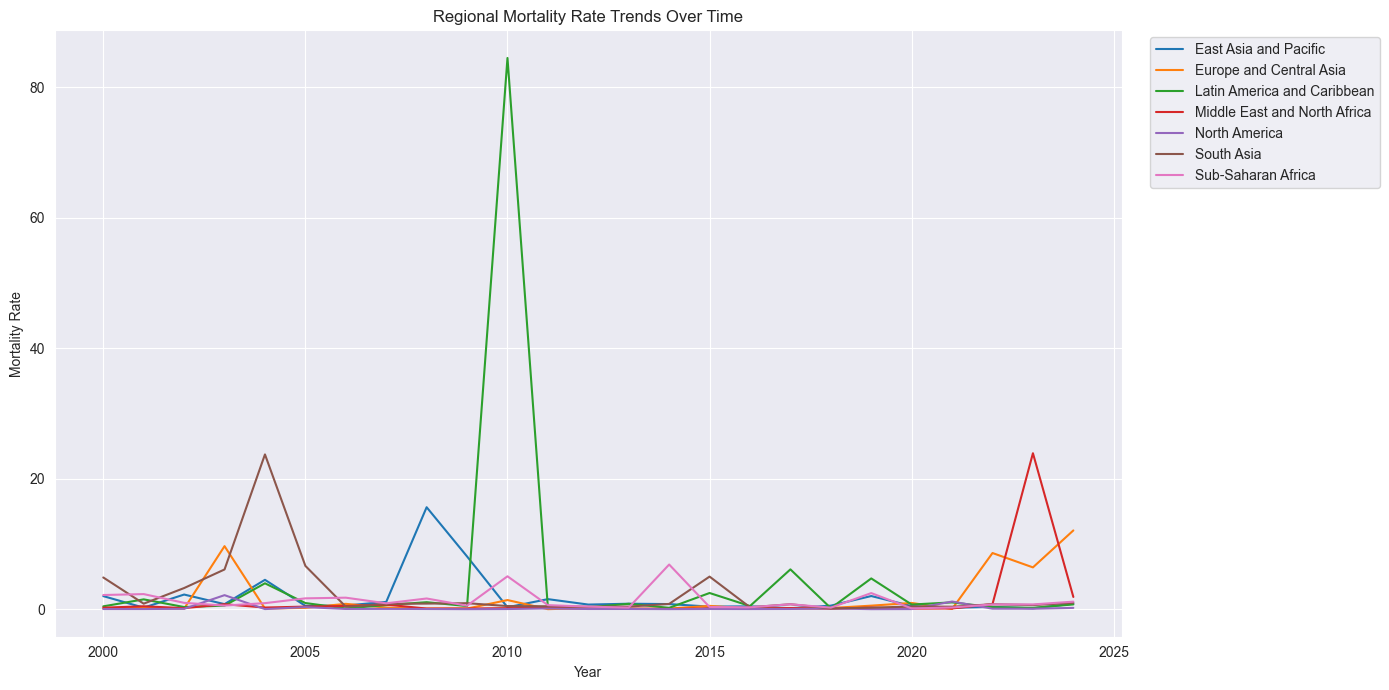

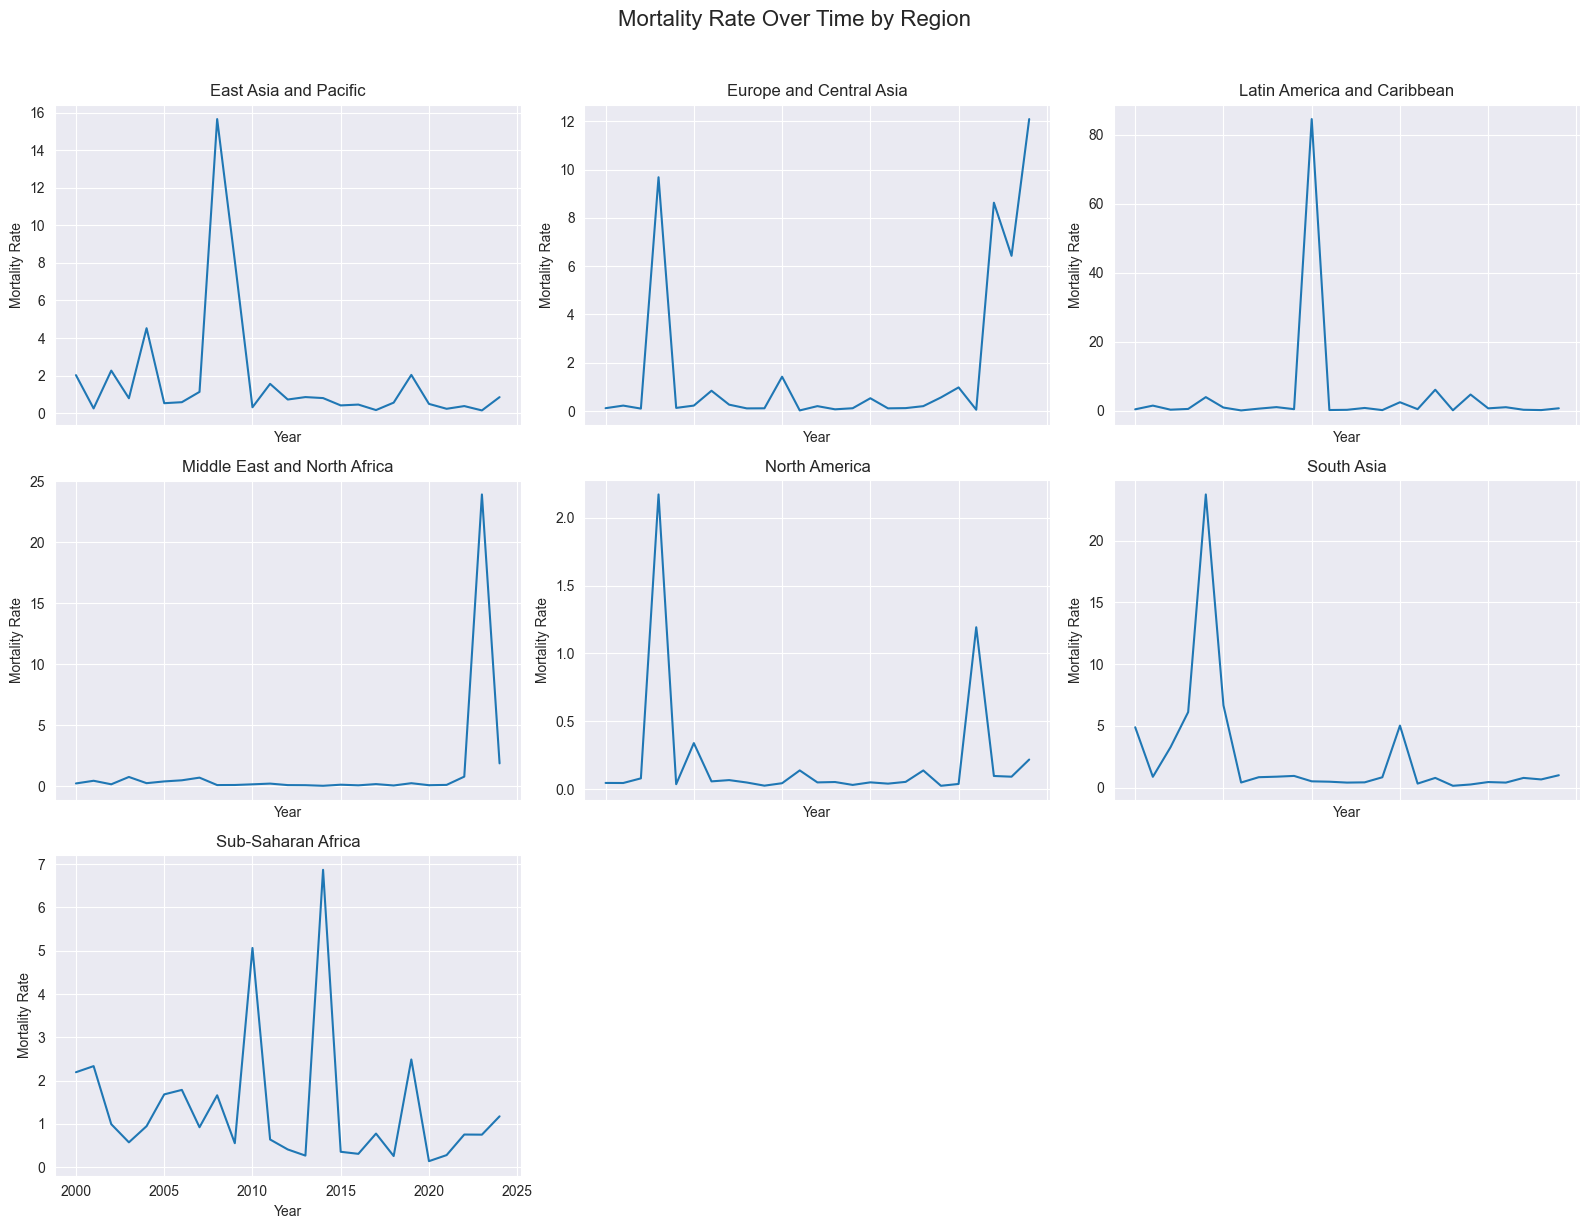

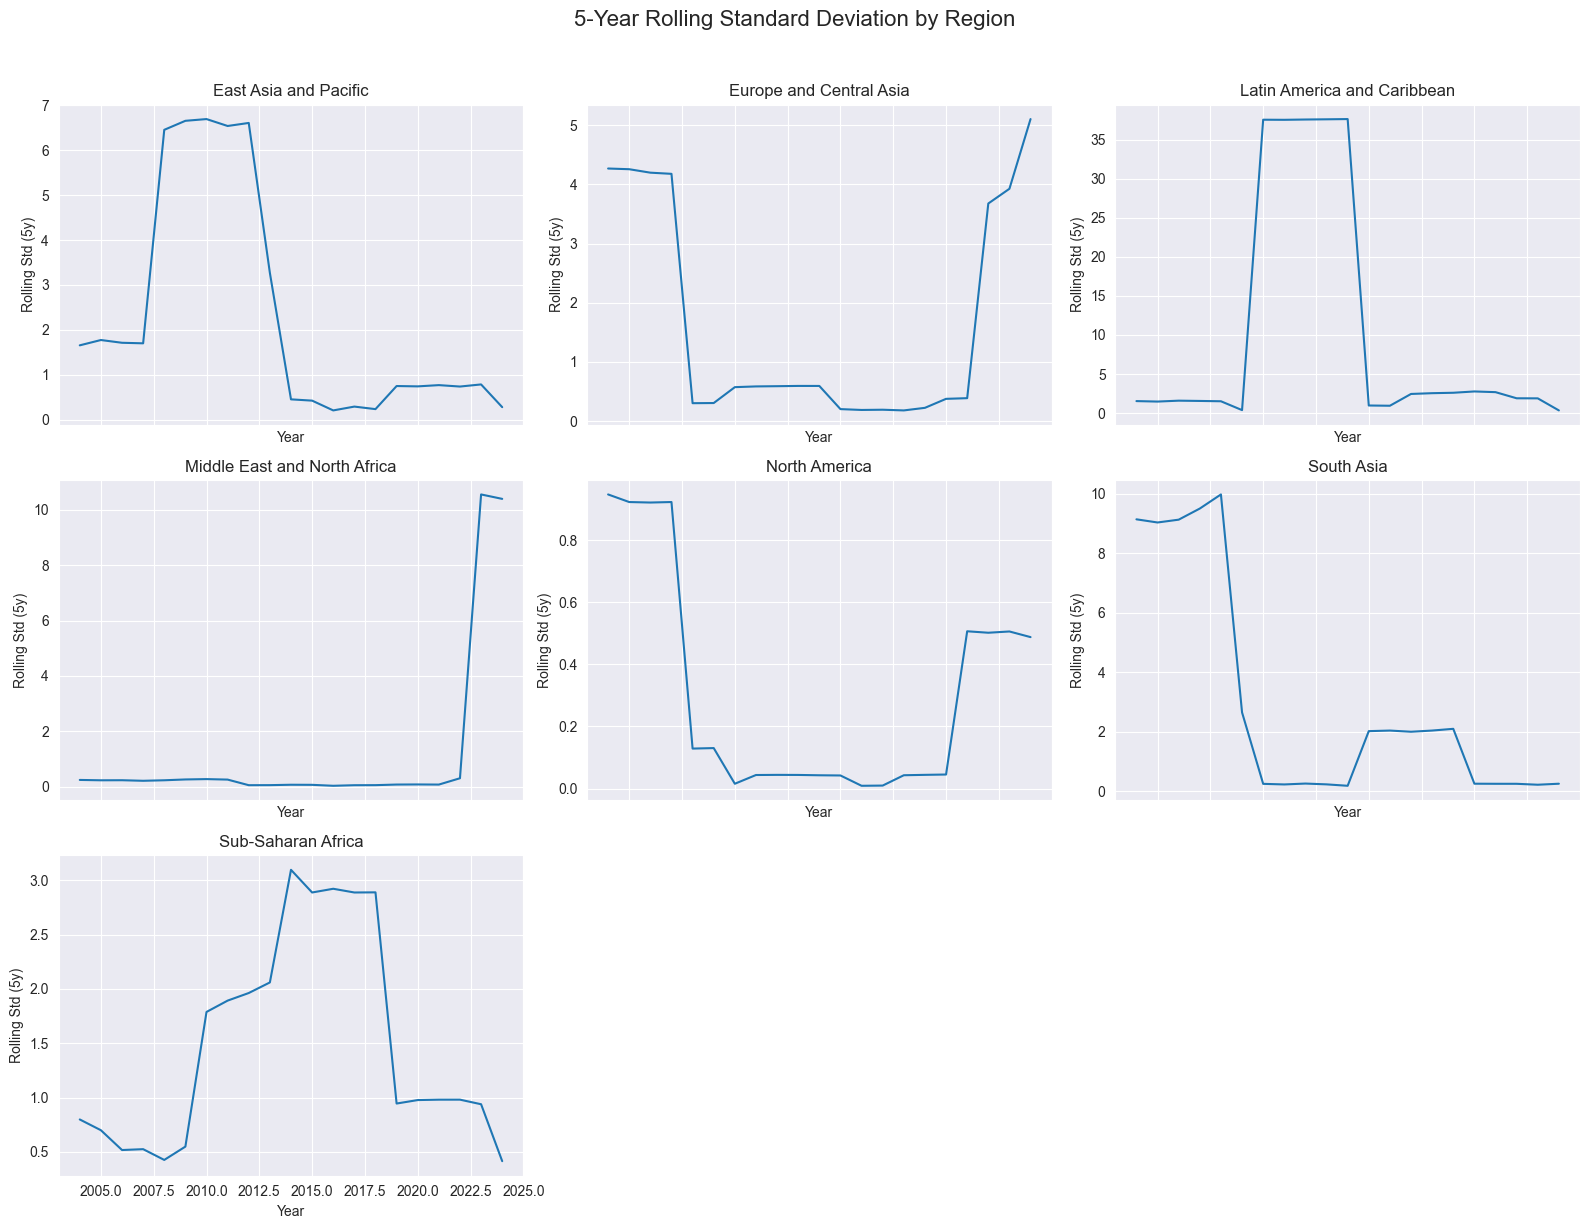

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ==== Prep ====
region_trend = (
    df.groupby(["Year", "Region"])["Mortality_Rate"]
    .mean()
    .reset_index()
)

regions = sorted(df["Region"].dropna().unique())

# 4.2.1 Comparative
plt.figure(figsize=(14, 7))
sns.lineplot(data=region_trend, x="Year", y="Mortality_Rate", hue="Region")
plt.title("Regional Mortality Rate Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Mortality Rate")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 4.2.2 Individual Region Trend

n = len(regions)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)

for i, region in enumerate(regions):
    ts = (
        df[df["Region"] == region]
        .groupby("Year")["Mortality_Rate"]
        .mean()
        .sort_index()
    )
    ax = axes[i]
    ax.plot(ts.index, ts.values)
    ax.set_title(f"{region}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Mortality Rate")

# tắt ô dư
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Mortality Rate Over Time by Region", y=1.02, fontsize=16)
fig.tight_layout()
plt.show()

# =========================
# 4.2.3 Rolling Volatility - gộp subplots
# =========================
window = 5
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)

for i, region in enumerate(regions):
    ts = (
        df[df["Region"] == region]
        .groupby("Year")["Mortality_Rate"]
        .mean()
        .sort_index()
    )
    rolling_std = ts.rolling(window=window).std()

    ax = axes[i]
    ax.plot(rolling_std.index, rolling_std.values)
    ax.set_title(f"{region}")
    ax.set_xlabel("Year")
    ax.set_ylabel(f"Rolling Std ({window}y)")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle(f"{window}-Year Rolling Standard Deviation by Region", y=1.02, fontsize=16)
fig.tight_layout()
plt.show()


In [34]:
# 4.2.4 ADF Summary Table
rows = []
for region in regions:
    ts = (
        df[df["Region"] == region]
        .groupby("Year")["Mortality_Rate"]
        .mean()
        .sort_index()
        .dropna()
    )

    if len(ts) > 3:  # tránh lỗi khi chuỗi quá ngắn
        pval = adfuller(ts)[1]
        rows.append([region, pval, float(ts.std()), int(ts.shape[0])])

region_adf_summary = pd.DataFrame(
    rows, columns=["Region", "ADF_pvalue", "StdDev", "NumYears"]
).sort_values("ADF_pvalue")

region_adf_summary

,Region,ADF_pvalue,StdDev,NumYears
6,Sub-Saharan Africa,2.965647e-07,1.565515,25
4,North America,8.692378e-06,0.470760,25
2,Latin America and Caribbean,2.071107e-05,16.733449,25
3,Middle East and North Africa,2.215038e-04,4.733307,25
0,East Asia and Pacific,1.000827e-02,3.349188,25
5,South Asia,1.881268e-02,4.849688,25
1,Europe and Central Asia,8.875757e-01,3.448301,25


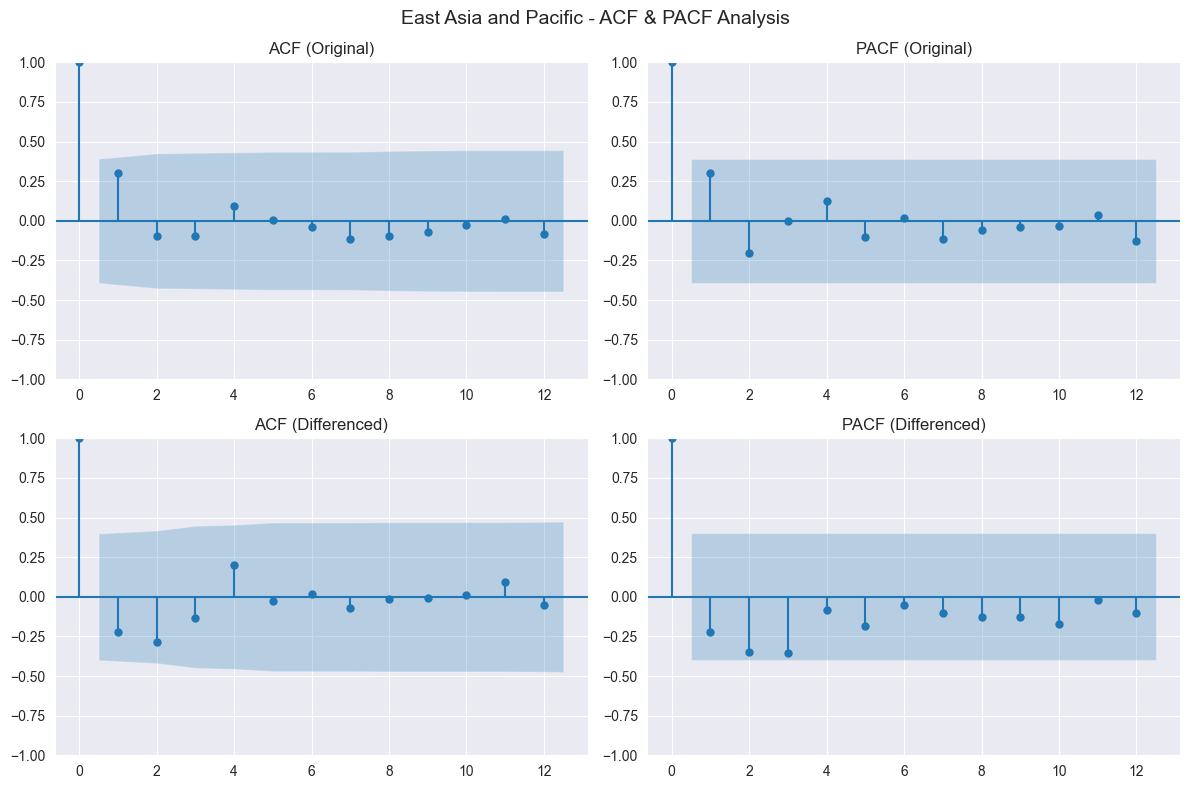

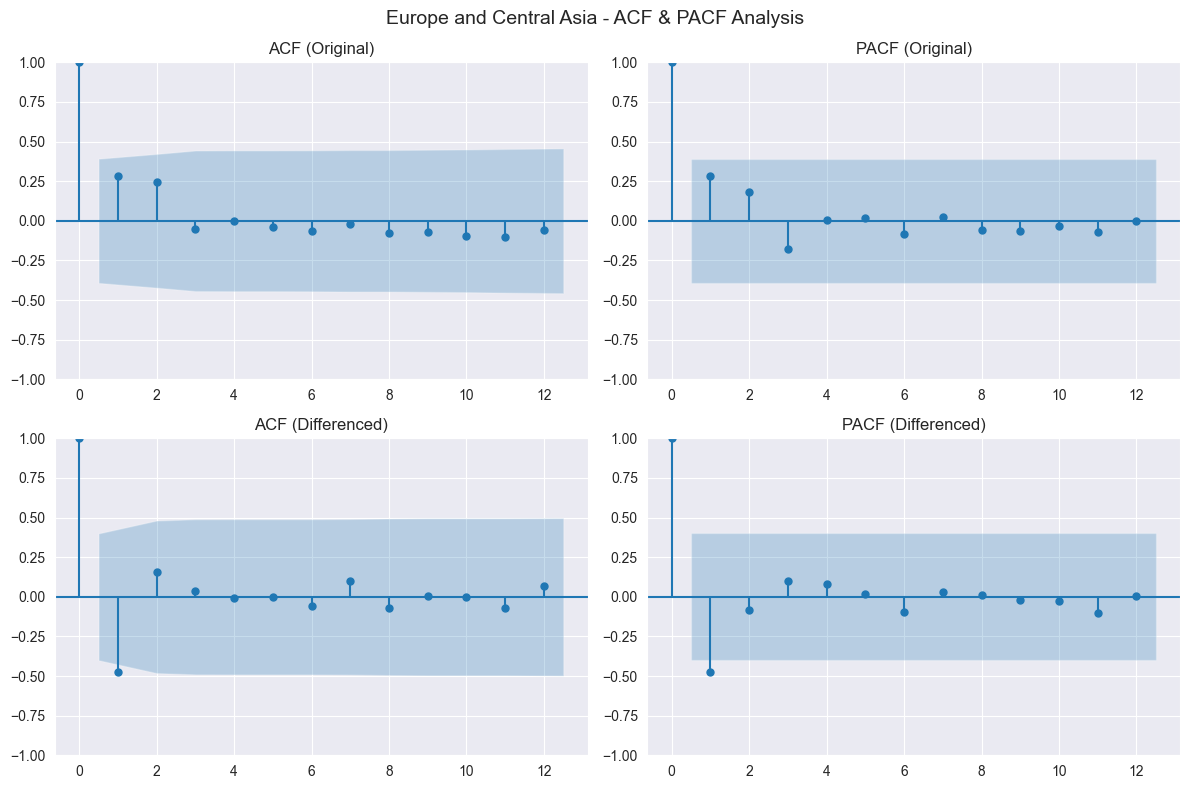

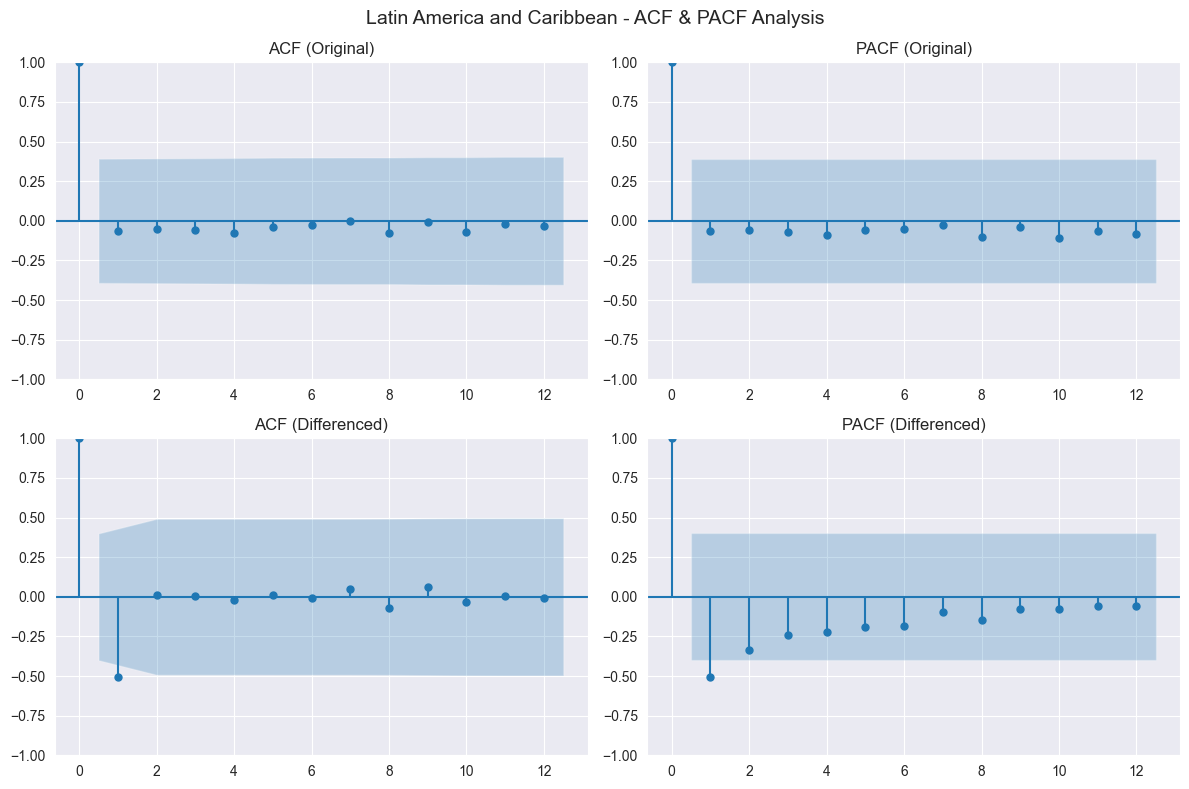

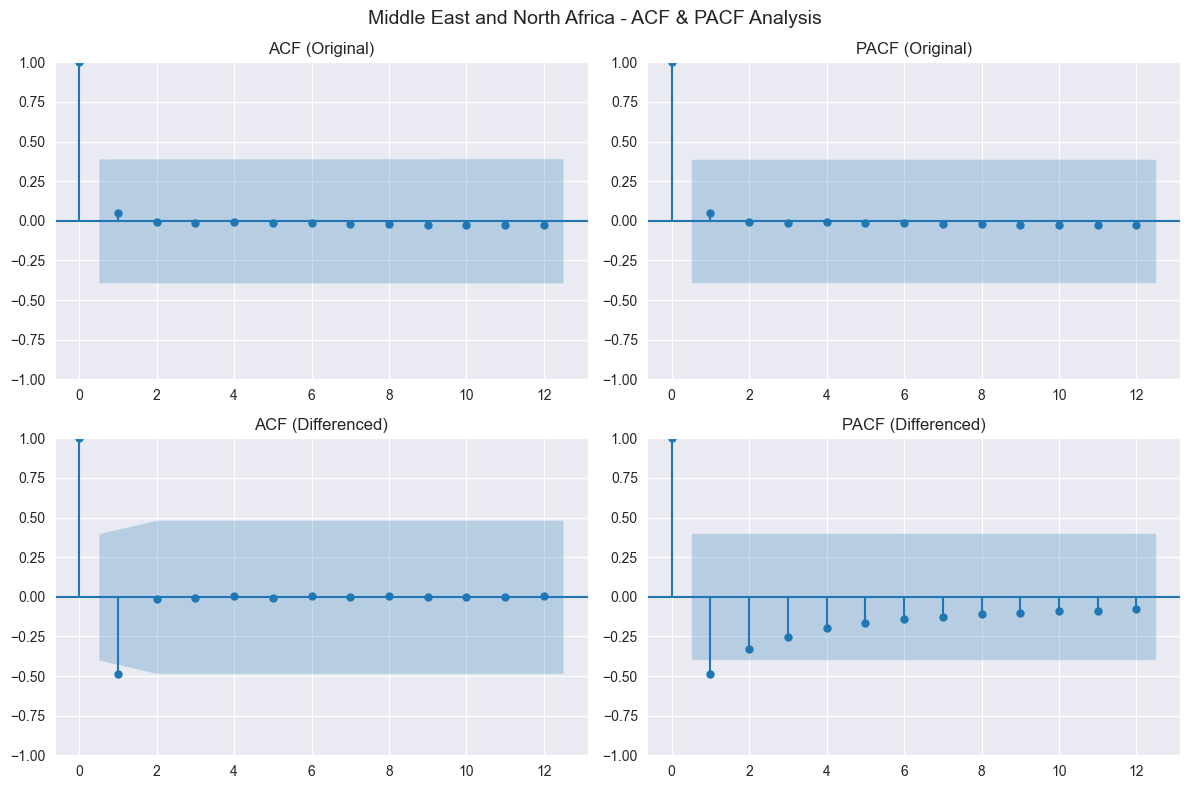

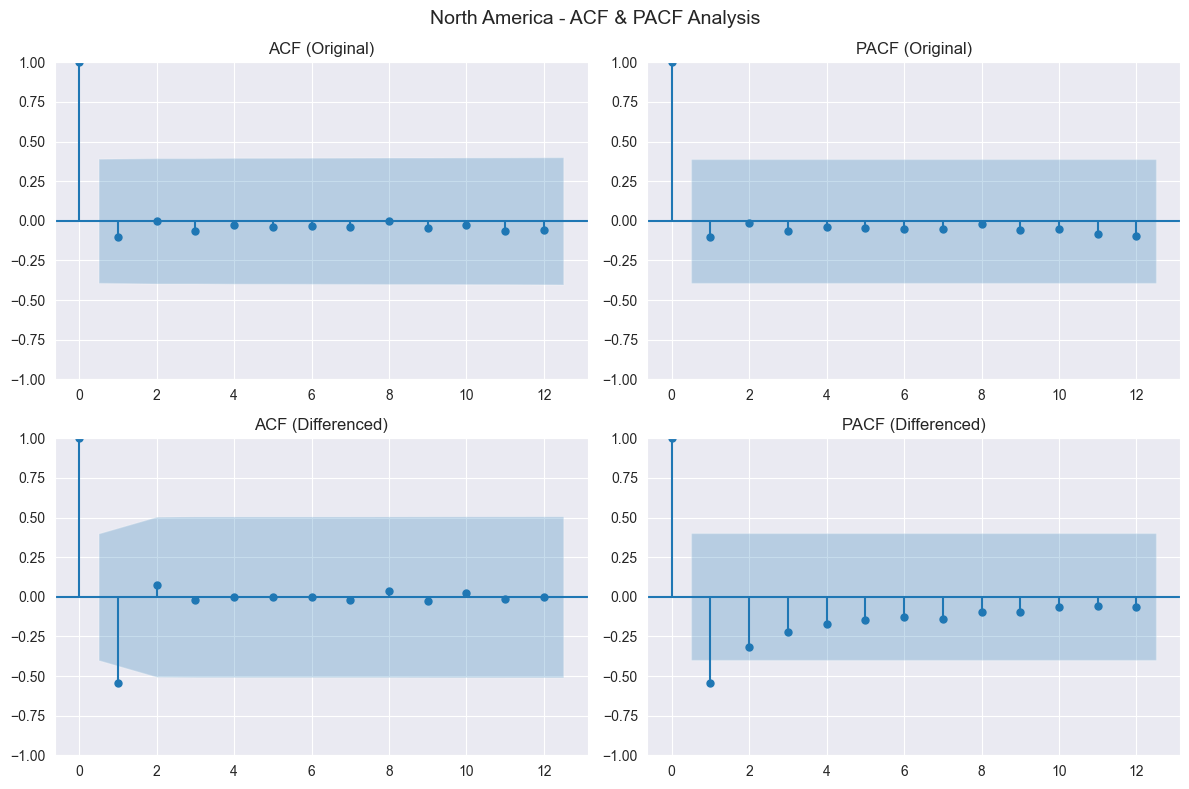

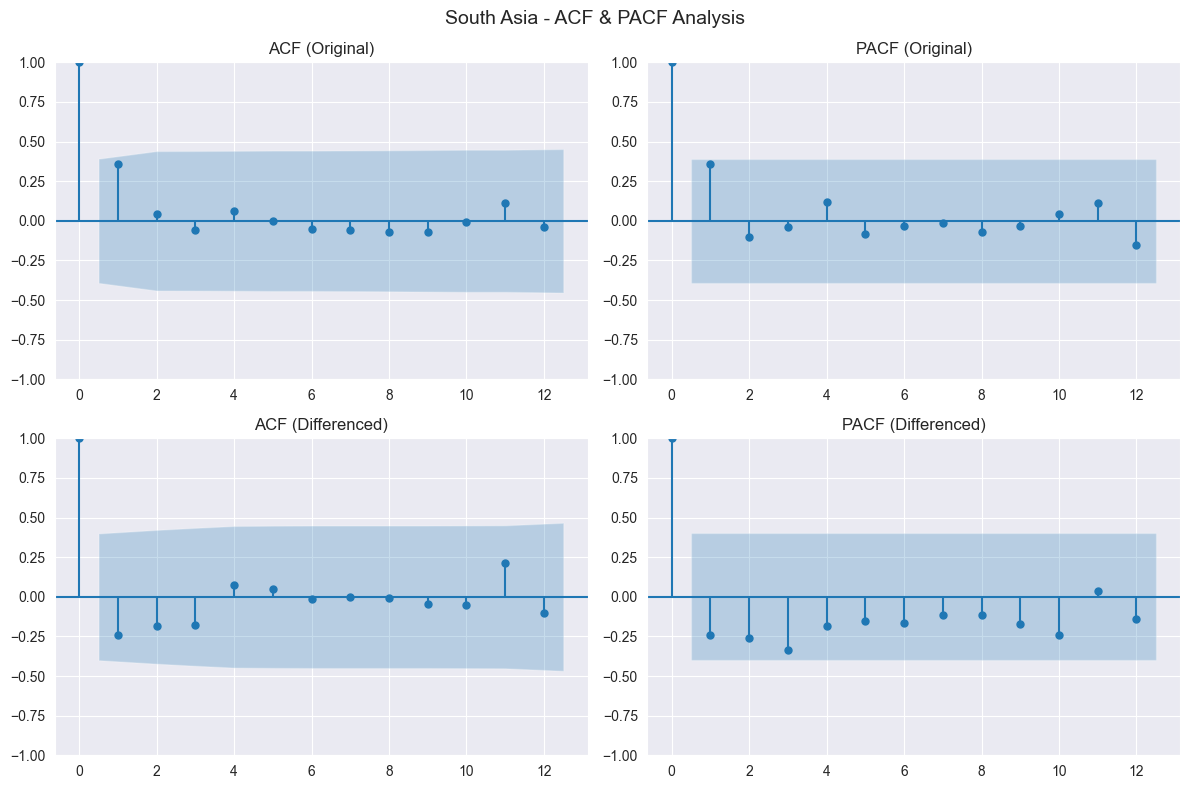

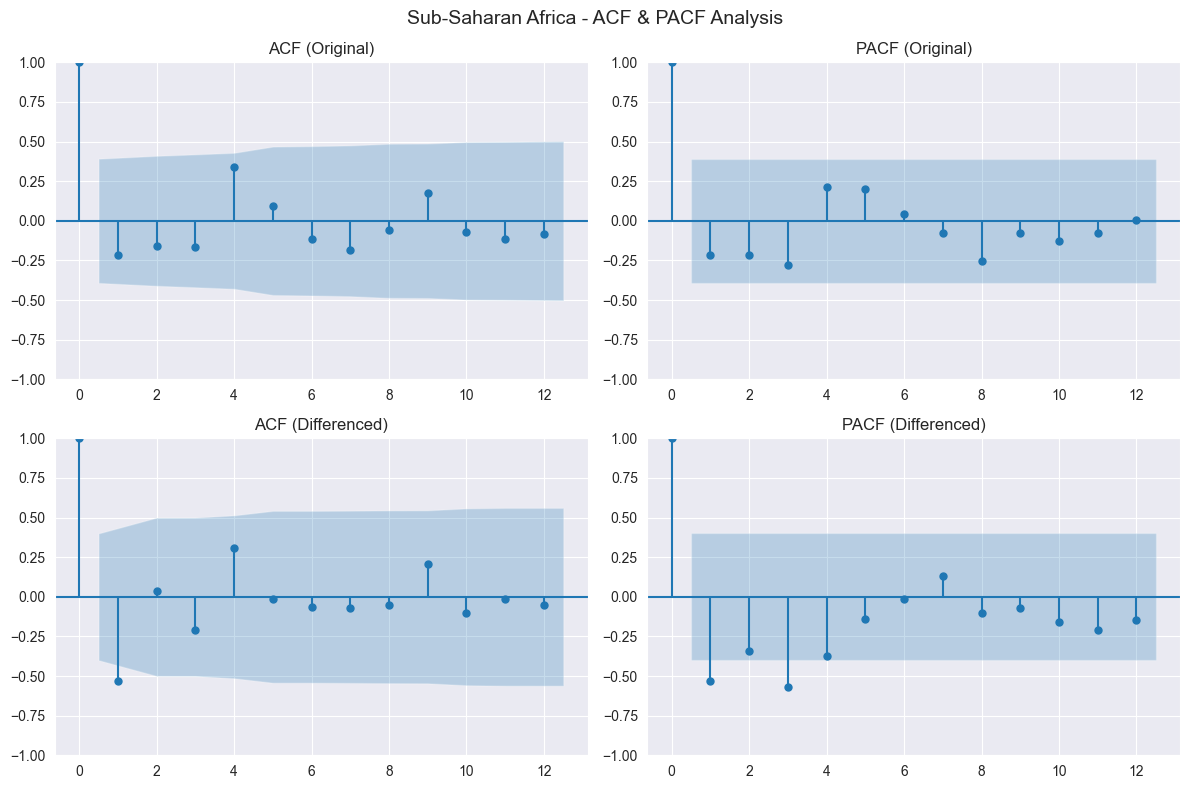

In [33]:

# 4.2.5 ACF & PACF
for region in regions:

    ts = (
        df[df["Region"] == region]
        .groupby("Year")["Mortality_Rate"]
        .mean()
        .sort_index()
        .dropna()
    )

    # bỏ qua nếu dữ liệu quá ít
    if len(ts) < 5:
        print(f"Skipping {region} (not enough data)")
        continue

    diff_ts = ts.diff().dropna()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Original series
    plot_acf(ts, ax=axes[0, 0])
    axes[0, 0].set_title("ACF (Original)")

    plot_pacf(ts, ax=axes[0, 1], method="ywm")
    axes[0, 1].set_title("PACF (Original)")

    # Differenced series
    plot_acf(diff_ts, ax=axes[1, 0])
    axes[1, 0].set_title("ACF (Differenced)")

    plot_pacf(diff_ts, ax=axes[1, 1], method="ywm")
    axes[1, 1].set_title("PACF (Differenced)")

    fig.suptitle(f"{region} - ACF & PACF Analysis", fontsize=14)
    fig.tight_layout()
    plt.show()

# 4.3 SELECTED COUNTRY-LEVEL ANALYSIS

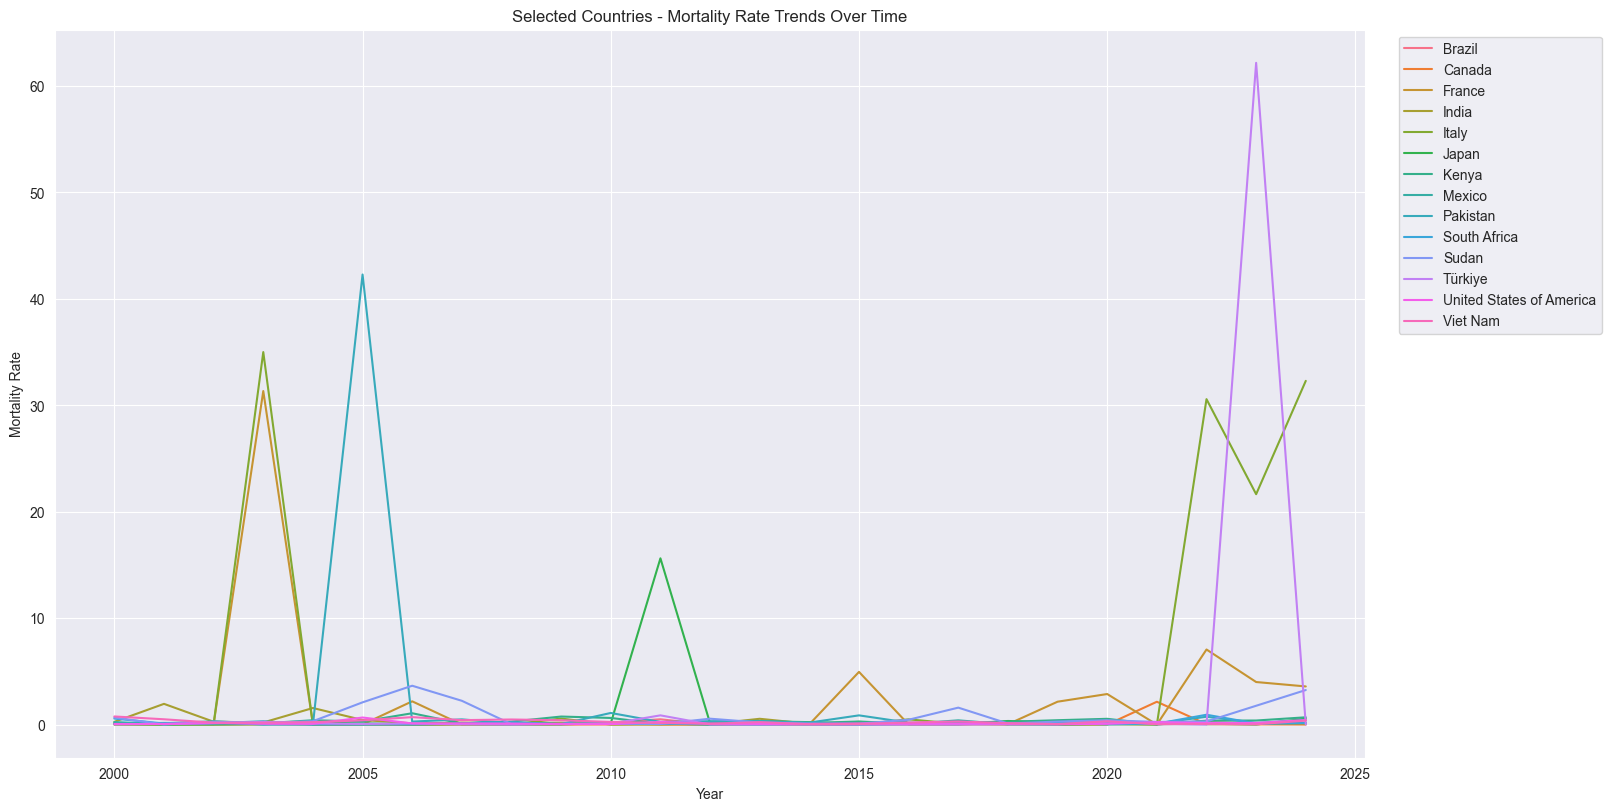

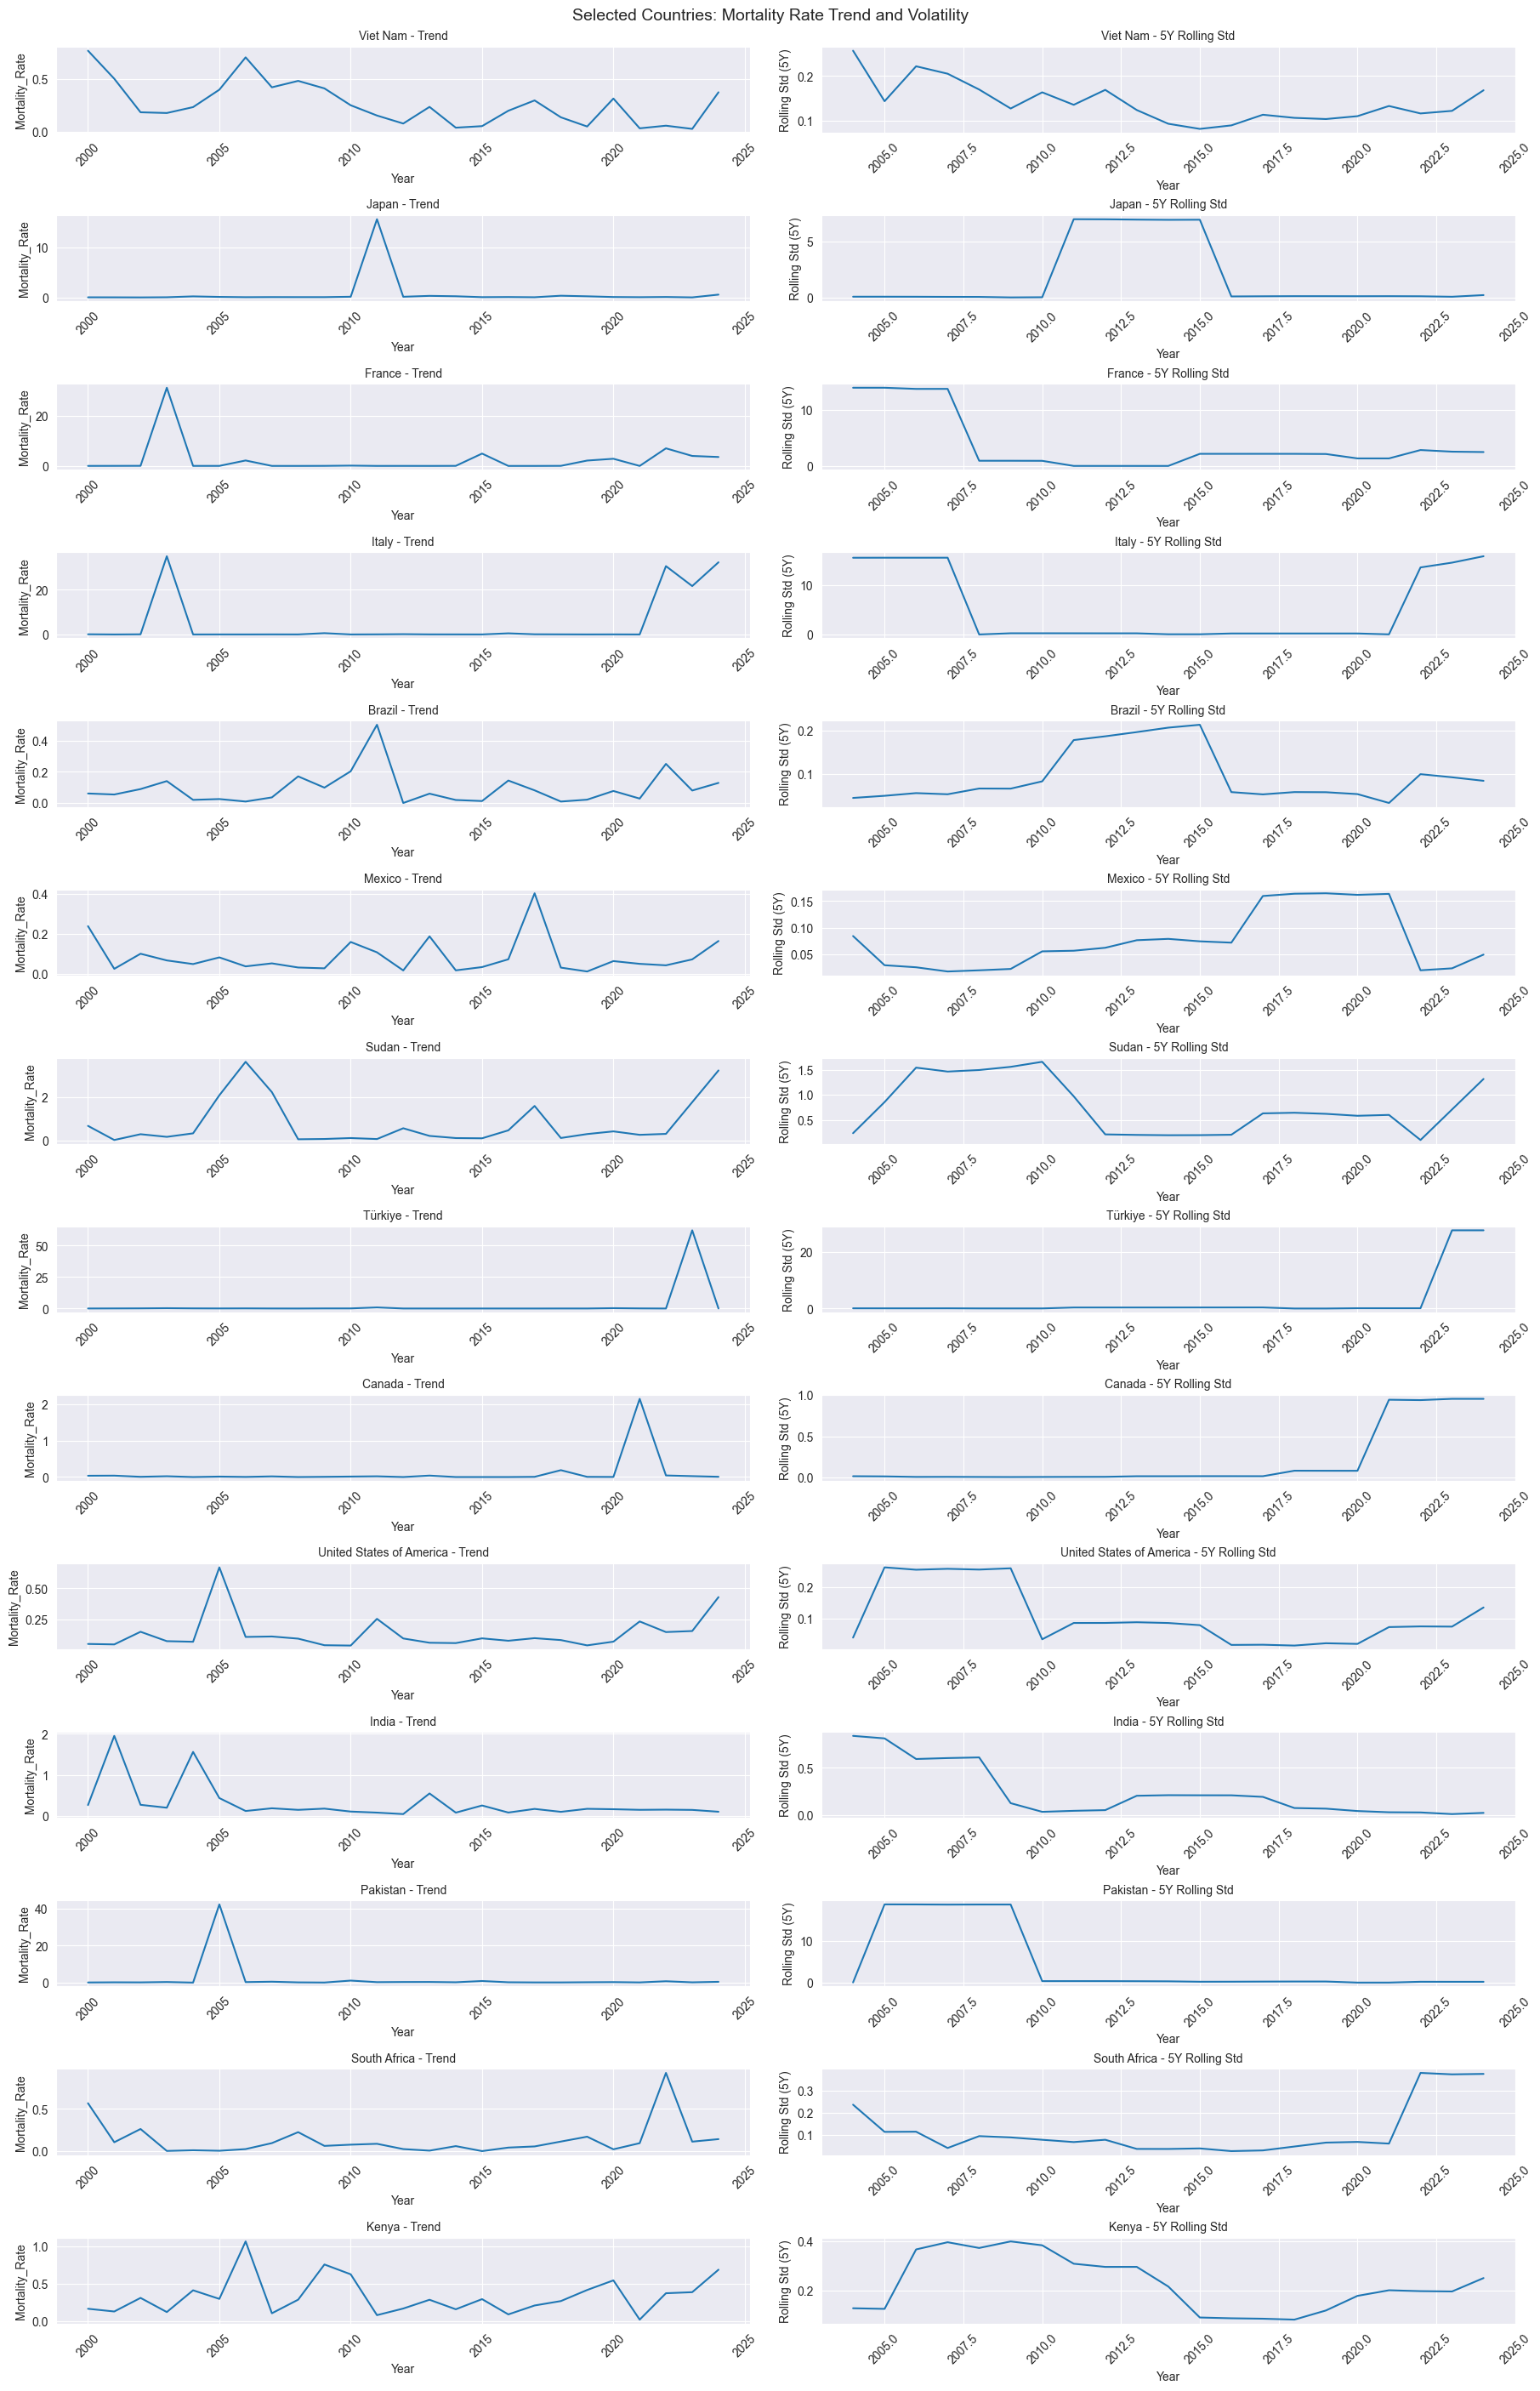

In [26]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# 4.3.1 Define Selected Countries

selected_countries = [
    "Viet Nam", "Japan",
    "France", "Italy",
    "Brazil", "Mexico",
    "Sudan", "Türkiye",
    "Canada", "United States of America",
    "India", "Pakistan",
    "South Africa", "Kenya"
]

country_df = df[df["Country"].isin(selected_countries)].copy()


# 4.3.2 Country Trend Comparison (All Selected Countries)

plt.figure(figsize=(16,8), constrained_layout=True)
sns.lineplot(data=country_df, x="Year", y="Mortality_Rate", hue="Country")
plt.title("Selected Countries - Mortality Rate Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Mortality Rate")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()
plt.close()


# 4.3.3–4.3.4 Trend + Rolling Volatility

plot_df = (
    df[df["Country"].isin(selected_countries)]
    .groupby(["Country", "Year"])["Mortality_Rate"]
    .mean()
    .reset_index()
    .sort_values(["Country", "Year"])
)

countries = selected_countries
n = len(countries)

fig, axes = plt.subplots(
    nrows=n, ncols=2,
    figsize=(18, 2.0 * n),
    constrained_layout=True
)

for i, c in enumerate(countries):
    ts = plot_df[plot_df["Country"] == c].sort_values("Year").copy()
    ts["roll_std_5y"] = ts["Mortality_Rate"].rolling(5).std()

    axes[i, 0].plot(ts["Year"], ts["Mortality_Rate"])
    axes[i, 0].set_title(f"{c} - Trend", fontsize=10)
    axes[i, 0].set_xlabel("Year")
    axes[i, 0].set_ylabel("Mortality_Rate")
    axes[i, 0].tick_params(axis="x", labelrotation=45)

    axes[i, 1].plot(ts["Year"], ts["roll_std_5y"])
    axes[i, 1].set_title(f"{c} - 5Y Rolling Std", fontsize=10)
    axes[i, 1].set_xlabel("Year")
    axes[i, 1].set_ylabel("Rolling Std (5Y)")
    axes[i, 1].tick_params(axis="x", labelrotation=45)

fig.suptitle("Selected Countries: Mortality Rate Trend and Volatility", fontsize=14)
plt.show()
plt.close()


In [28]:
# 4.3.5 Stationarity (ADF) Summary Table
rows = []
for country in selected_countries:
    ts = (
        country_df[country_df["Country"] == country]
        .groupby("Year")["Mortality_Rate"]
        .mean()
        .sort_index()
        .dropna()
    )

    # ADF needs enough points + non-constant series
    if ts.shape[0] < 3 or np.isclose(ts.max(), ts.min()):
        pval = np.nan
    else:
        try:
            pval = adfuller(ts)[1]
        except Exception:
            pval = np.nan

    rows.append([country, pval, float(ts.std()) if ts.shape[0] else np.nan, int(ts.shape[0])])

country_adf_summary = (
    pd.DataFrame(rows, columns=["Country", "ADF_pvalue", "StdDev", "NumYears"])
    .sort_values("StdDev", ascending=False)
)

country_adf_summary

,Country,ADF_pvalue,StdDev,NumYears
7,Türkiye,9.970815e-01,12.945027,23
3,Italy,6.491356e-01,11.338524,25
11,Pakistan,2.580073e-01,8.403840,25
2,France,1.257132e-05,6.344719,25
1,Japan,3.643538e-05,3.102961,25
6,Sudan,2.574979e-01,1.044281,24
10,India,2.467428e-01,0.453341,25
8,Canada,9.867810e-01,0.436215,24
13,Kenya,5.419285e-02,0.248781,25
12,South Africa,2.090742e-05,0.208701,24


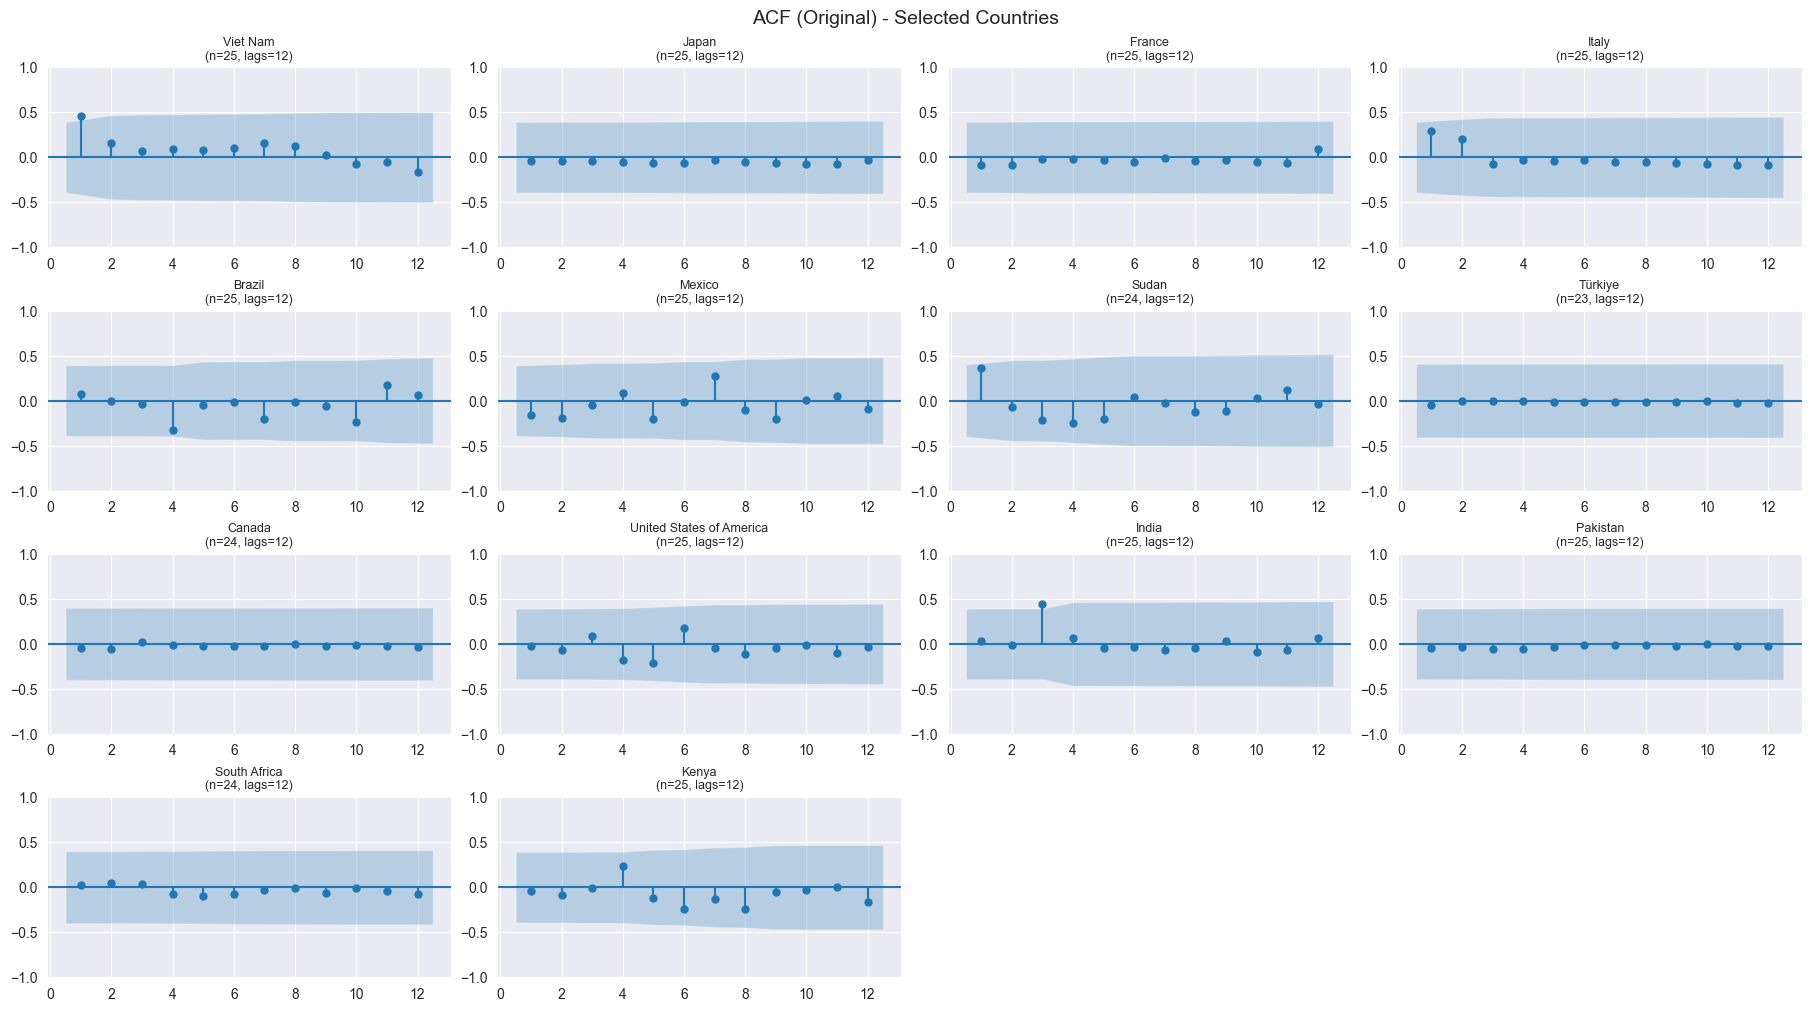

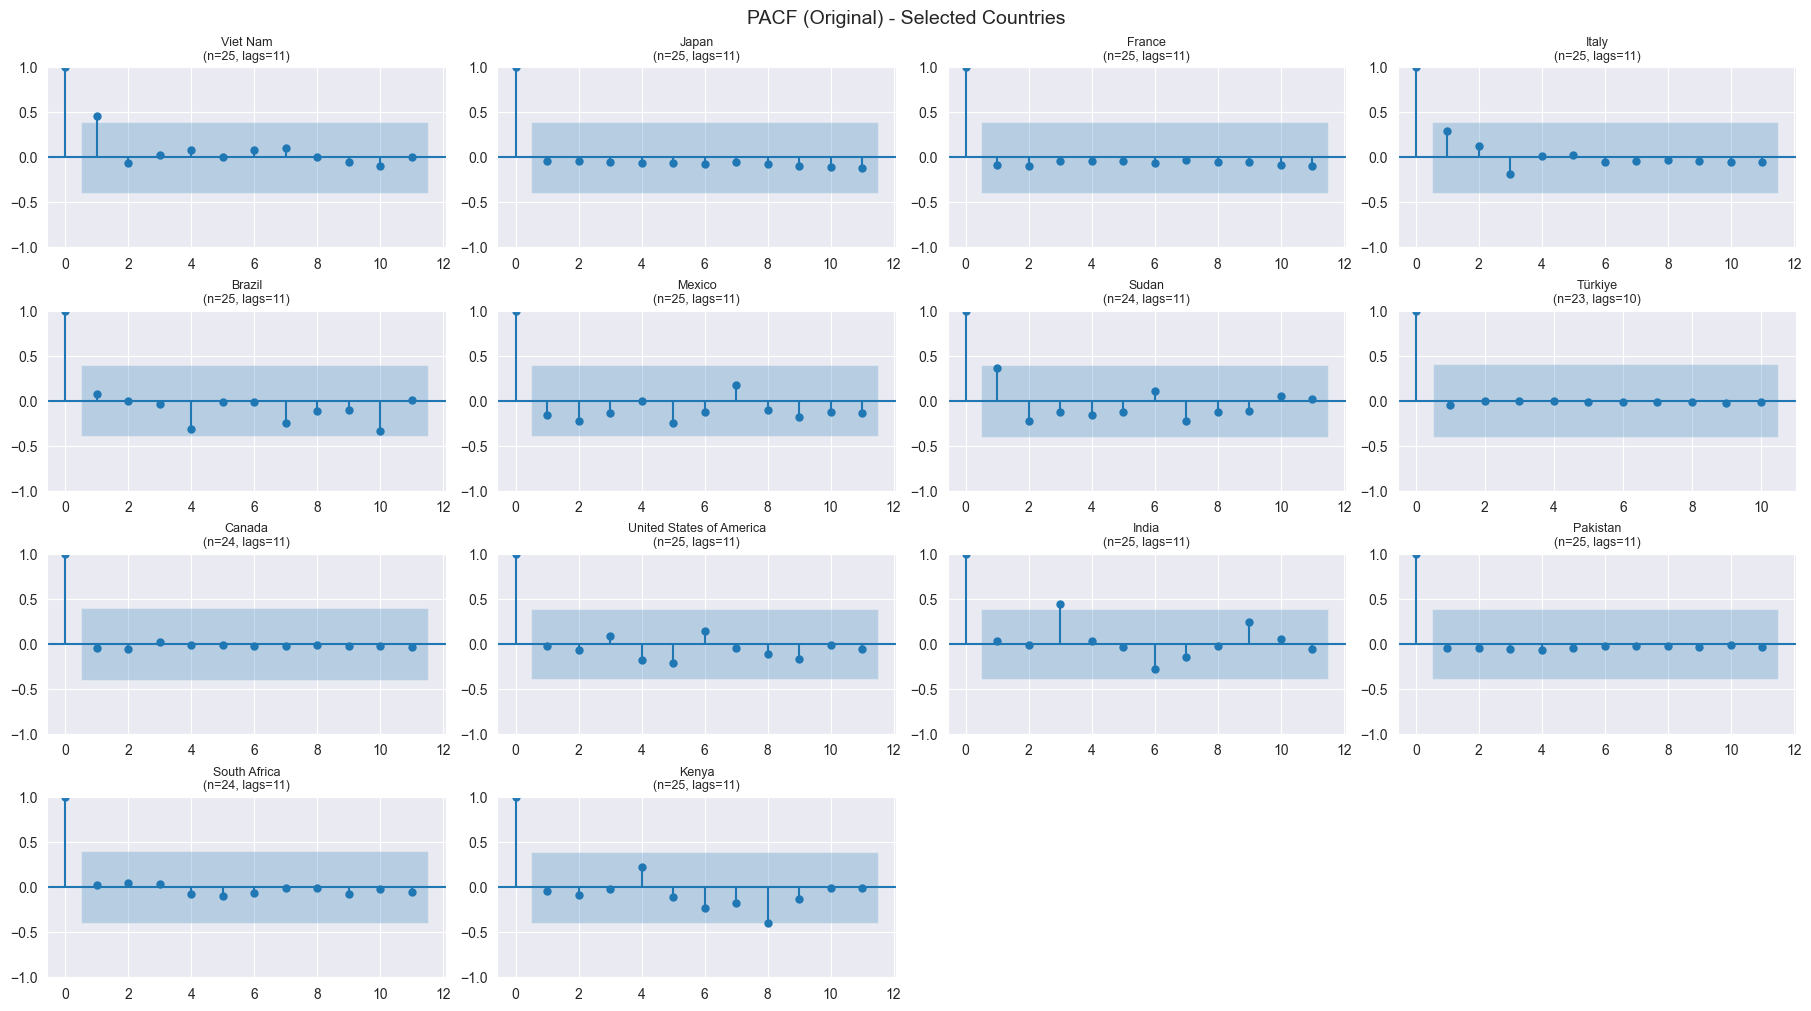

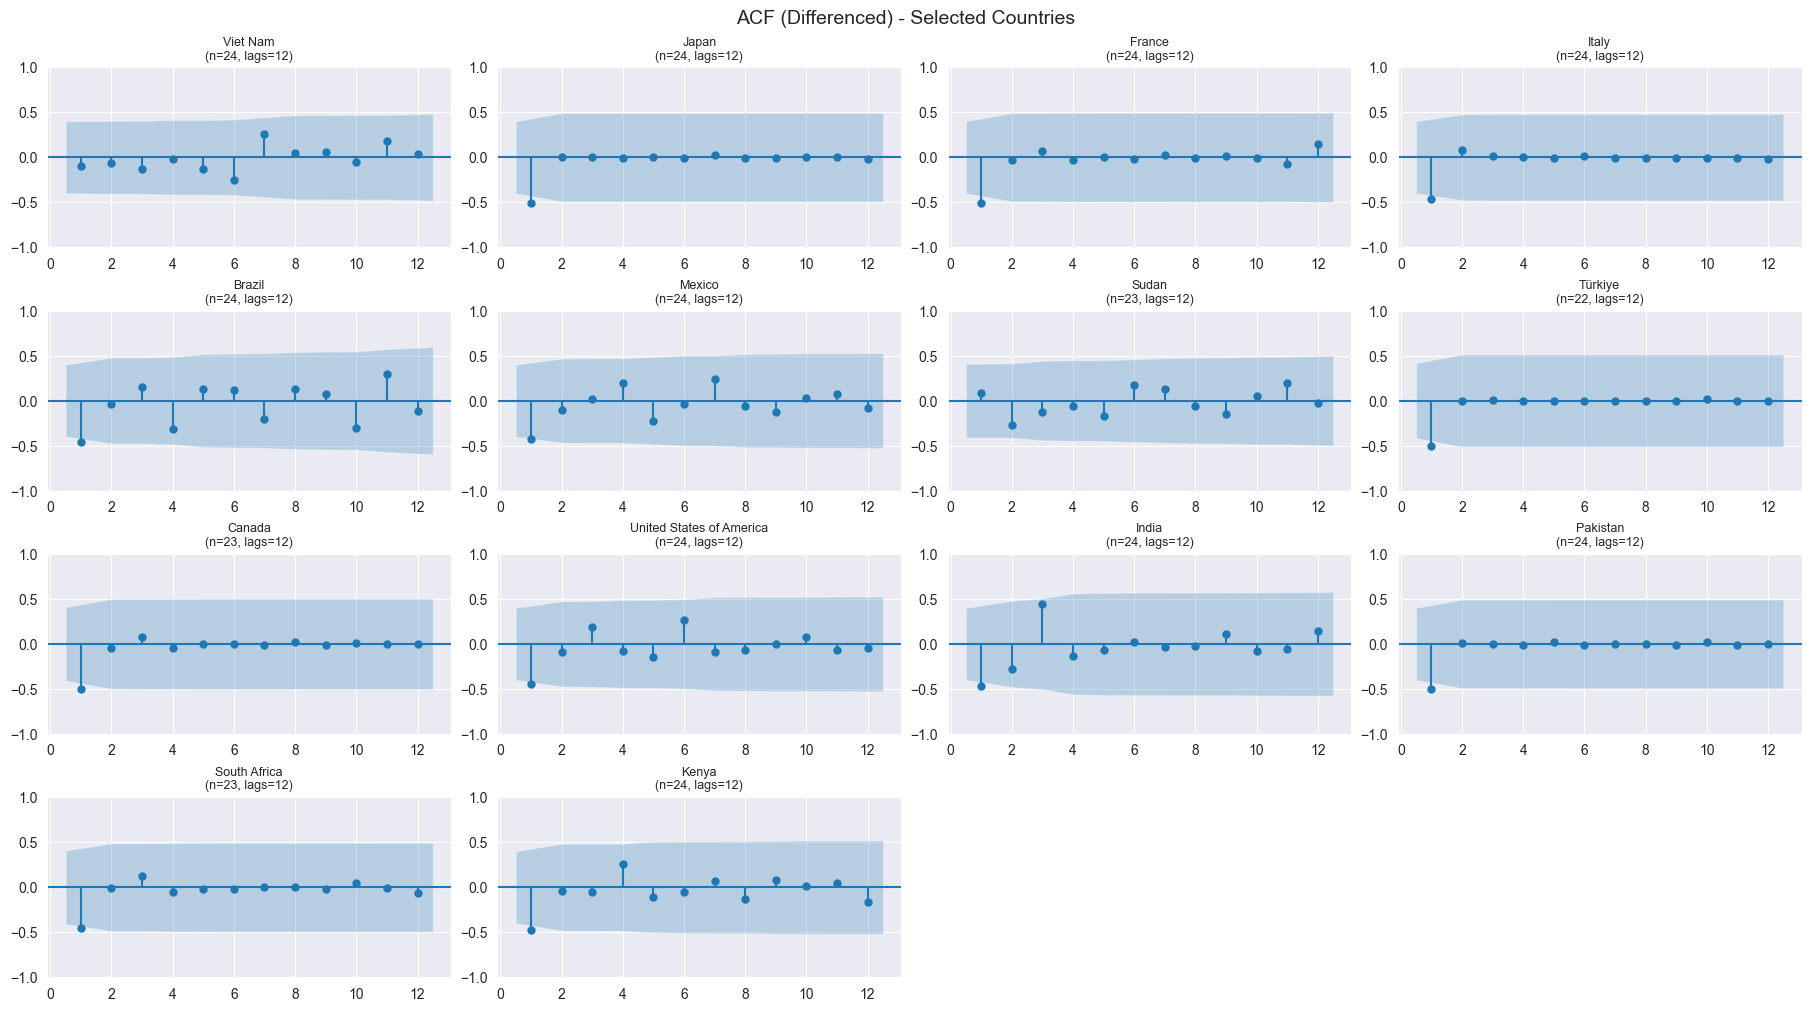

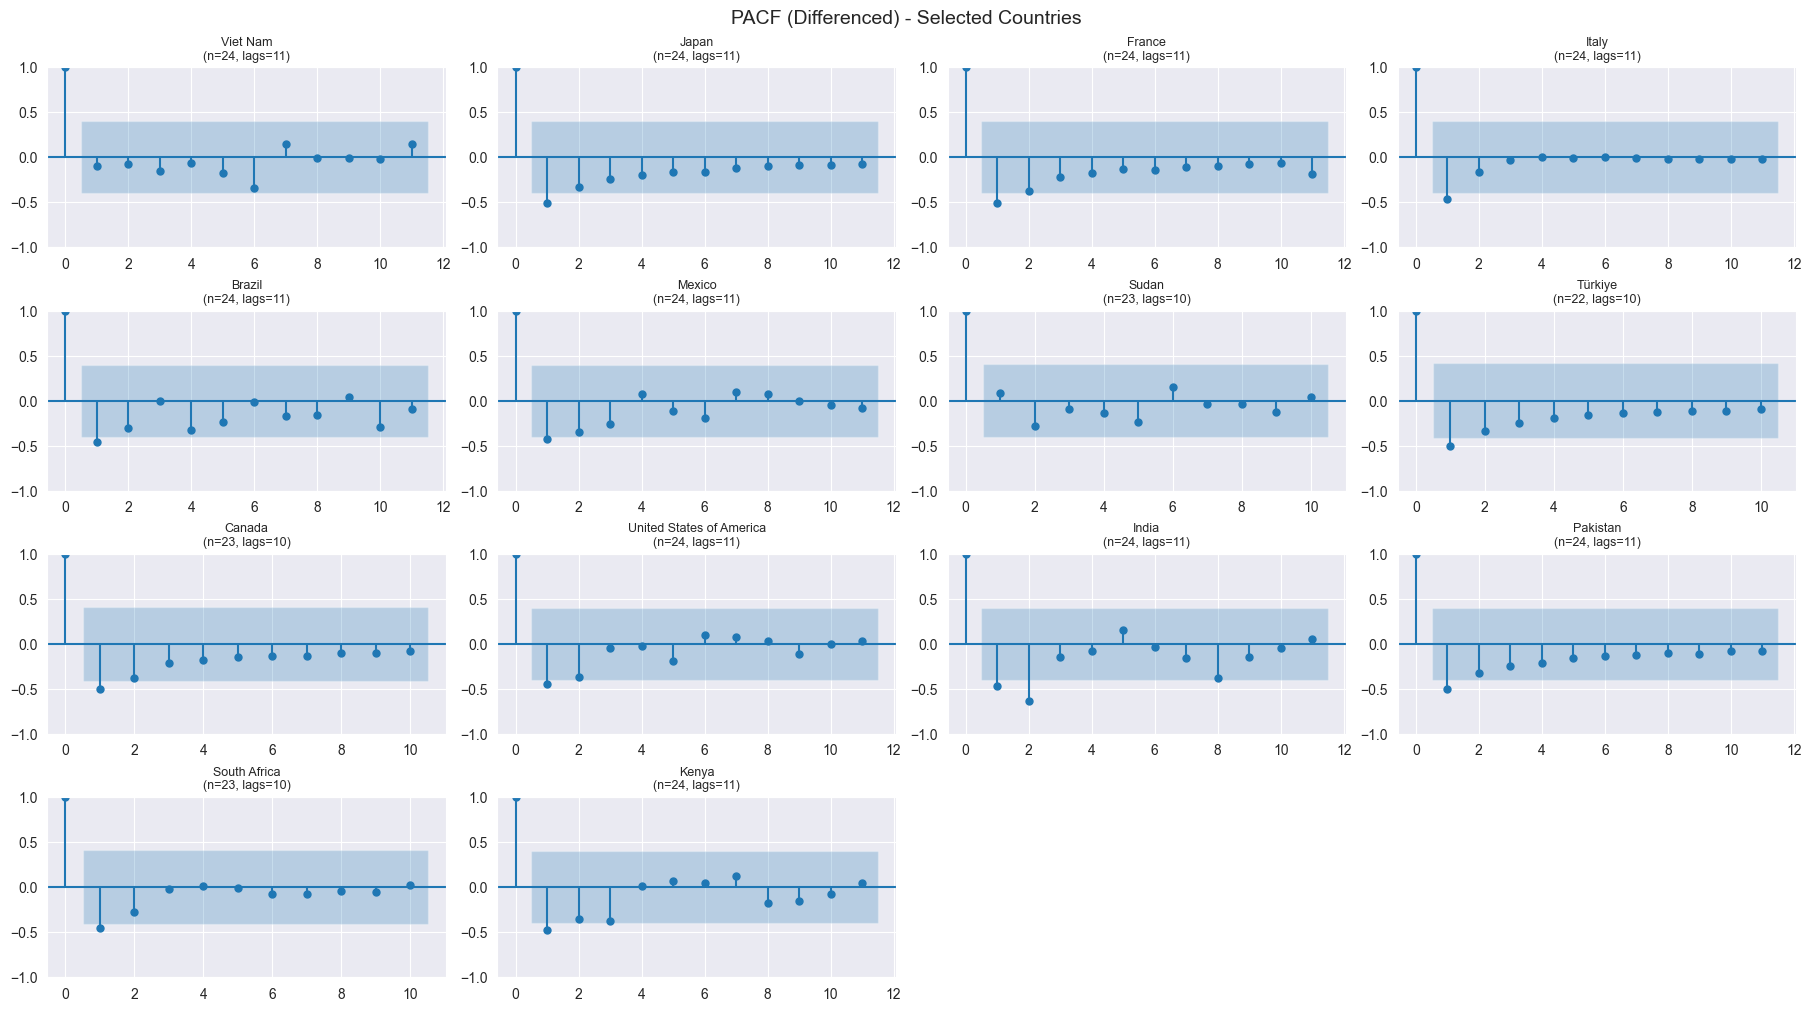

In [29]:
# 4.3.6 ACF & PACF (Selected Countries)

def _get_country_ts(country: str):
    return (
        country_df[country_df["Country"] == country]
        .groupby("Year")["Mortality_Rate"]
        .mean()
        .sort_index()
        .dropna()
    )

def plot_grid_acf_pacf(kind="acf", series="original", nlags=12, ncols=4, figsize=(18, 10)):
    countries = selected_countries
    n = len(countries)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    for i, country in enumerate(countries):
        ax = axes[i]
        ts = _get_country_ts(country)

        if series == "diff":
            ts = ts.diff().dropna()

        nobs = ts.shape[0]

        if nobs == 0:
            ax.text(0.5, 0.5, "EMPTY", ha="center", va="center")
            ax.set_title(country, fontsize=9)
            ax.axis("off")
            continue

        if nobs < 8 or np.isclose(ts.max(), ts.min()):
            ax.text(0.5, 0.5, "N/A", ha="center", va="center")
            ax.set_title(country, fontsize=9)
            ax.axis("off")
            continue

        # clamp nlags to avoid statsmodels PACF constraint: nlags < nobs/2
        max_lags = (nobs // 2) - 1 if kind == "pacf" else (nobs - 1)
        if max_lags < 1:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center")
            ax.set_title(country, fontsize=9)
            ax.axis("off")
            continue

        nlags_use = min(nlags, int(max_lags))

        if kind == "acf":
            plot_acf(ts, ax=ax, lags=nlags_use, zero=False)
        else:
            plot_pacf(ts, ax=ax, lags=nlags_use, method="ywm")

        ax.set_title(f"{country}\n(n={nobs}, lags={nlags_use})", fontsize=9)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{kind.upper()} ({'Original' if series=='original' else 'Differenced'}) - Selected Countries",
        fontsize=14
    )
    plt.show()
    plt.close(fig)

# Original
plot_grid_acf_pacf(kind="acf",  series="original", nlags=12)
plot_grid_acf_pacf(kind="pacf", series="original", nlags=12)

# Differenced
plot_grid_acf_pacf(kind="acf",  series="diff", nlags=12)
plot_grid_acf_pacf(kind="pacf", series="diff", nlags=12)